<a href="https://colab.research.google.com/github/Shreyans06/LLMs-understanding/blob/main/Fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fine-tuning for Classification

In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(
    url,
    zip_path,
    extracted_path,
    data_file_path
  ):
  if data_file_path.exists():
    print(f"{data_file_path} already exists. Skipping download and extraction.")
    return

  with urllib.request.urlopen(url) as response:
    with open(zip_path, "wb") as out_file:
      out_file.write(response.read())

  with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extracted_path)

  original_file_path = Path(extracted_path) / "SMSSpamCollection"
  os.rename(original_file_path, data_file_path)
  print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


In [2]:
import pandas as pd
df = pd.read_csv(
    data_file_path, sep='\t' , header=None, names=["Label" , "Text"]
)

In [3]:
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
def create_balanced_dataset(df):
  num_spam = df[df["Label"] == "spam"].shape[0]
  ham_subset = df[df["Label"] == "ham"].sample(
      num_spam, random_state=123
  )
  balanced_df = pd.concat([
      ham_subset,
      df[df["Label"] == "spam"]
  ])
  return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [6]:
balanced_df["Label"] = balanced_df["Label"].map({"ham" : 0 , "spam" : 1})

In [7]:
def random_split(df , train_frac, val_frac):
  df = df.sample(
      frac= 1,
      random_state = 123
  ).reset_index(drop=True)
  train_end = int(len(df) * train_frac)
  validation_end = train_end + int(len(df) * val_frac)

  train_df = df[:train_end]
  val_df = df[train_end: validation_end]
  test_df = df[validation_end:]

  return train_df, val_df, test_df

train_df, val_df, test_df = random_split(balanced_df, 0.7 , 0.1)

In [8]:
train_df.to_csv("train.csv" , index=None)
val_df.to_csv("validation.csv" , index=None)
test_df.to_csv("test.csv" , index=None)

In [9]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>" , allowed_special={"<|endoftext|>"}))

[50256]


In [10]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
  def __init__(self , csv_file, tokenizer, max_length=None, pad_token_id=50256):
    self.data = pd.read_csv(csv_file)

    self.encoded_texts = [
        tokenizer.encode(text) for text in self.data["Text"]

    ]

    if max_length is None:
      self.max_length = self._longest_encoded_length()
    else:
      self.max_length = max_length

      self.encoded_texts = [
          encoded_text[:self.max_length]
          for encoded_text in self.encoded_texts
      ]

    self.encoded_texts = [
        encoded_text + [pad_token_id] *
        (self.max_length - len(encoded_text))
        for encoded_text in self.encoded_texts
    ]

  def __getitem__(self, index):
    encoded = self.encoded_texts[index]
    label = self.data.iloc[index]["Label"]
    return (
        torch.tensor(encoded, dtype=torch.long),
        torch.tensor(label, dtype=torch.long)
    )

  def __len__(self):
    return len(self.data)

  def _longest_encoded_length(self):
    max_length = 0
    for encoded_text in self.encoded_texts:
      encoded_length = len(encoded_text)
      if encoded_length > max_length:
        max_length = encoded_length
    return max_length

In [11]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

In [12]:
print(train_dataset.max_length)

120


In [13]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [14]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [15]:
MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size" : 50257,
    "context_length" : 1024,
    "drop_rate" : 0.0,
    "qkv_bias" : True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[MODEL])

In [16]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7a5facbf54c0>)

In [17]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/previous_chapters.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('previous_chapters.py', <http.client.HTTPMessage at 0x7a5facbf6cf0>)

In [18]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_generate.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_generate.py', <http.client.HTTPMessage at 0x7a5facbf7440>)

In [19]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel
from gpt_generate import load_weights_into_gpt

model_size = MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings , params = download_and_load_gpt2(
    model_size = model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 129kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 638kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 295kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [02:58<00:00, 2.80MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 9.93MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 470kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 459kiB/s]


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [20]:
from gpt_generate import text_to_token_ids, token_ids_to_text
from previous_chapters import generate_text_simple

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids,tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [21]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


In [22]:
for param in model.parameters():
  param.requires_grad = False

In [23]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

In [24]:
for param in model.trf_blocks[-1].parameters():
  param.requires_grad = True
for param in model.final_norm.parameters():
  param.requires_grad = True

In [25]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Input dimension:", inputs.shape)

Inputs: tensor([[5211,  345,  423,  640]])
Input dimension: torch.Size([1, 4])


In [26]:
with torch.no_grad():
  outputs = model(inputs)
print("Outputs:\n", outputs)
print("Output dimension:", outputs.shape)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Output dimension: torch.Size([1, 4, 2])


In [27]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


In [28]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


In [29]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
  model.eval()
  correct_predictions, num_examples = 0 , 0

  if num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))

  for i , (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      input_batch, target_batch = input_batch.to(device), target_batch.to(device)
      with torch.no_grad():
        logits = model(input_batch)[:, -1, :]
      predicted_labels = torch.argmax(logits, dim=-1)

      num_examples += predicted_labels.shape[0]
      correct_predictions += (
          (predicted_labels == target_batch).sum().item()
      )
    else:
      break

  return correct_predictions / num_examples

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model , device , num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model , device , num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model , device , num_batches=10
)
print(f"Train accuracy: {train_accuracy*100:.4f}%")
print(f"Validation accuracy: {val_accuracy*100:.4f}%")
print(f"Test accuracy: {test_accuracy*100:.4f}%")

Train accuracy: 46.2500%
Validation accuracy: 45.0000%
Test accuracy: 48.7500%


In [31]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch, target_batch = input_batch.to(device) , target_batch.to(device)
  logits = model(input_batch)[:, -1, :]
  loss = torch.nn.functional.cross_entropy(logits, target_batch)
  return loss

In [32]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0.
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))

  for i , (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(
          input_batch, target_batch, model, device
      )
      total_loss += loss.item()
    else:
      break

  return total_loss / num_batches

In [33]:
with torch.no_grad():
  train_loss = calc_loss_loader(
      train_loader, model, device, num_batches=5
  )
  val_loss = calc_loss_loader(
      val_loader, model, device, num_batches=5
  )
  test_loss = calc_loss_loader(
      test_loader, model, device, num_batches=5
  )
print(f"Train loss: {train_loss:.4f}")
print(f"Validation loss: {val_loss:.4f}")
print(f"Test loss: {test_loss:.4f}")

Train loss: 2.4530
Validation loss: 2.5830
Test loss: 2.3220


In [34]:
def train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter):
  train_losses , val_losses , train_accs , val_accs = [] , [] , [] , []
  examples_seen , global_step = 0 , -1

  for epoch in range(num_epochs):
    model.train()

    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch(
          input_batch, target_batch, model, device
      )
      loss.backward()
      optimizer.step()
      examples_seen += input_batch.shape[0]
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss , val_loss = evaluate_model(
            model, train_loader, val_loader, device, eval_iter
        )
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch + 1} (Step {global_step:06d}): "
              f"Train loss {train_loss:.3f}, "
              f"Val loss {val_loss:.3f}"
        )

    train_accuracy = calc_accuracy_loader(
          train_loader, model, device, num_batches=eval_iter
      )

    val_accuracy = calc_accuracy_loader(
          val_loader, model, device, num_batches=eval_iter
      )

    print(f"Training accuracy: {train_accuracy * 100:.2f}% | ", end="")
    print(f"Validation accuracy: {val_accuracy * 100:.2f}%")
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)

  return train_losses, val_losses, train_accs, val_accs, examples_seen



In [35]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=eval_iter
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=eval_iter
    )
    model.train()
    return train_loss, val_loss

In [36]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    eval_freq=50,
    eval_iter=5
)

end_time = time.time()
execution_time_min = (end_time - start_time) / 60
print(f"Training completed in {execution_time_min:.2f} minutes.")

Epoch 1 (Step 000000): Train loss 2.153, Val loss 2.392
Epoch 1 (Step 000050): Train loss 0.617, Val loss 0.637
Epoch 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Epoch 2 (Step 000150): Train loss 0.561, Val loss 0.489
Epoch 2 (Step 000200): Train loss 0.419, Val loss 0.397
Epoch 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Epoch 3 (Step 000300): Train loss 0.333, Val loss 0.320
Epoch 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Epoch 4 (Step 000400): Train loss 0.136, Val loss 0.200
Epoch 4 (Step 000450): Train loss 0.153, Val loss 0.132
Epoch 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Epoch 5 (Step 000550): Train loss 0.207, Val loss 0.143
Epoch 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accurac

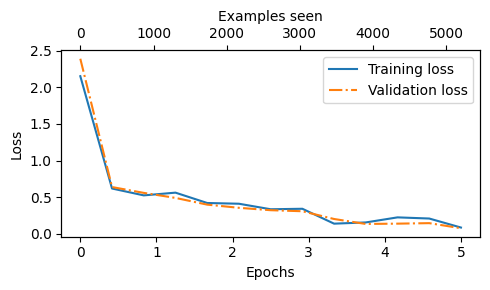

In [37]:
import matplotlib.pyplot as plt
def plot_values(
    epochs_seen, examples_seen, train_values, val_values,
    label = "loss"):
  fig , ax1 = plt.subplots(figsize=(5,3))

  ax1.plot(epochs_seen, train_values, label=f"Training {label}")
  ax1.plot(
      epochs_seen, val_values, linestyle="-.",
      label=f"Validation {label}"
  )
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel(label.capitalize())
  ax1.legend()

  ax2 = ax1.twiny()
  ax2.plot(examples_seen, train_values, alpha=0)
  ax2.set_xlabel("Examples seen")

  fig.tight_layout()
  plt.savefig(f"{label}-plot.pdf")
  plt.show()

epochs_tensor = torch.linspace(0 , num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(
    epochs_tensor, examples_seen_tensor,
    train_losses, val_losses
)

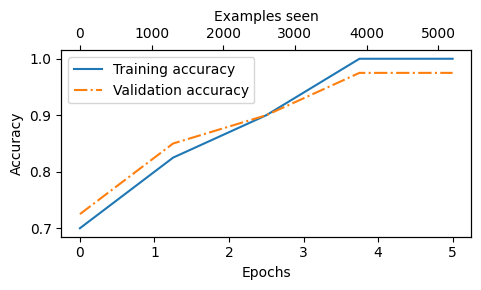

In [38]:
epochs_tensor = torch.linspace(0 , num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor,
    train_accs, val_accs, label="accuracy")

In [39]:
train_accuracy = calc_accuracy_loader(
    train_loader, model , device)
val_accuracy = calc_accuracy_loader(
    val_loader, model , device)
test_accuracy = calc_accuracy_loader(
    test_loader, model , device)
print(f"Train accuracy: {train_accuracy*100:.4f}%")
print(f"Validation accuracy: {val_accuracy*100:.4f}%")
print(f"Test accuracy: {test_accuracy*100:.4f}%")

Train accuracy: 97.2115%
Validation accuracy: 97.3154%
Test accuracy: 95.6667%


In [40]:
def classify_review(
    text, model, tokenizer, device, max_length=None,
    pad_token_id=50256):
  model.eval()

  input_ids = tokenizer.encode(text)
  supported_context_length = model.pos_emb.weight.shape[0]

  input_ids = input_ids[:min(
      max_length, supported_context_length
  )]

  input_ids += [pad_token_id] * (max_length - len(input_ids))

  input_tensor = torch.tensor(
      input_ids, device = device
  ).unsqueeze(0)

  with torch.no_grad():
    logits = model(input_tensor)[:, -1, :]

  predicted_label = torch.argmax(logits, dim=-1).item()

  return "spam" if predicted_label == 1 else "not spam"


In [41]:
text_1 = (
    "You are a winner and specially selected to"
    " receive $1000 in cash or a $3000 in award"
)
print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [42]:
text_2 = (
    "Hey, just checking if we're still talking"
)
print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [43]:
torch.save(model.state_dict(), "review_classifier.pth")

In [44]:
model_state_dict = torch.load("review_classifier.pth", map_location=device)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

Instruction Fine-tuning

In [45]:
import json
import os
import urllib.request

def download_and_load_file(file_path, url):
  if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
      text_data = response.read().decode("utf-8")
    with open(file_path, "w", encoding="utf-8") as file:
      file.write(text_data)

  with open(file_path, "r") as file:
    data = json.load(file)

  return data

file_path = "instruction-response-pair-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [46]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [47]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


In [48]:
def format_input(entry):
  instruction_text = (
      f"Below is an instruction that describes a task."
      f"Write a response that appropriately completes the request.\n\n"
      f"### Instruction:\n{entry['instruction']}"
  )

  input_text = (
      f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
  )

  return instruction_text + input_text

In [49]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [50]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [51]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion: train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


In [52]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
  def __init__(self, data, tokenizer):
    self.data = data
    self.encoded_texts = []
    for entry in data:
      instruction_plus_input = format_input(entry)
      response_text = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction_plus_input + response_text
      self.encoded_texts.append(
          tokenizer.encode(full_text)
      )

  def __getitem__(self, index):
    return self.encoded_texts[index]

  def __len__(self):
    return len(self.data)

In [53]:
def add_padding(
    batch,
    pad_token_id=50256,
    device="cpu"):
  batch_max_length = max(len(item) + 1 for item in batch)
  inputs_list = []

  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]

    padded = (
        new_item + [pad_token_id] *
        (batch_max_length - len(new_item))
    )
    inputs = torch.tensor(padded[:-1])
    inputs_list.append(inputs)

  inputs_tensor = torch.stack(inputs_list).to(device)
  return inputs_tensor


In [54]:
input_1 = [2,3,6,8,10]
input_2 = [1, 2, 3]
inputs_3 = [1 , 6]
batch = (
    input_1, input_2, inputs_3
)
print(add_padding(batch))

tensor([[    2,     3,     6,     8,    10],
        [    1,     2,     3, 50256, 50256],
        [    1,     6, 50256, 50256, 50256]])


In [56]:
def add_target_tokens(batch, pad_token_id=50256, device="cpu"):
  batch_max_length = max(len(item) + 1 for item in batch)
  inputs_list , target_list = [] , []

  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]

    padded = (
        new_item + [pad_token_id] *
        (batch_max_length - len(new_item))
    )
    inputs = torch.tensor(padded[:-1])
    targets = torch.tensor(padded[1:])
    inputs_list.append(inputs)
    target_list.append(targets)

  inputs_tensor = torch.stack(inputs_list).to(device)
  targets_tensor = torch.stack(target_list).to(device)
  return inputs_tensor, targets_tensor

inputs, targets = add_target_tokens(batch)
print(inputs)
print(targets)

tensor([[    2,     3,     6,     8,    10],
        [    1,     2,     3, 50256, 50256],
        [    1,     6, 50256, 50256, 50256]])
tensor([[    3,     6,     8,    10, 50256],
        [    2,     3, 50256, 50256, 50256],
        [    6, 50256, 50256, 50256, 50256]])


In [58]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_list , targets_list = [] , []

    for item in batch:
      new_item = item.copy()
      new_item += [pad_token_id]

      padded = (
          new_item + [pad_token_id] *
          (batch_max_length - len(new_item))
      )
      inputs = torch.tensor(padded[:-1])
      targets = torch.tensor(padded[1:])

      mask = targets == pad_token_id
      indices = torch.nonzero(mask).squeeze()
      if indices.numel() > 1:
        targets[indices[1:]] = ignore_index

      if allowed_max_length is not None:
        inputs = inputs[:allowed_max_length]
        targets = targets[:allowed_max_length]

      inputs_list.append(inputs)
      targets_list.append(targets)

    inputs_tensor = torch.stack(inputs_list).to(device)
    targets_tensor = torch.stack(targets_list).to(device)
    return inputs_tensor, targets_tensor


In [59]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    2,     3,     6,     8,    10],
        [    1,     2,     3, 50256, 50256],
        [    1,     6, 50256, 50256, 50256]])
tensor([[    3,     6,     8,    10, 50256],
        [    2,     3, 50256,  -100,  -100],
        [    6, 50256,  -100,  -100,  -100]])


In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [61]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [62]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [63]:
print("Train Loader")
for inputs, targets in train_loader:
  print(inputs.shape, targets.shape)

Train Loader
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.S

In [64]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel
from gpt_generate import load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size" : 50257,
    "context_length" : 1024,
    "drop_rate" : 0.0,
    "qkv_bias": True
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 224kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 747kiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 154kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [09:25<00:00, 2.51MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 19.2MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:01<00:00, 667kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 371kiB/s]


GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [65]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [67]:
from gpt_generate import text_to_token_ids, token_ids_to_text, generate

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [68]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active


In [69]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_train.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_train.py', <http.client.HTTPMessage at 0x7a5f0c3ade80>)

In [70]:
from gpt_train import (
    calc_loss_loader,
    train_model_simple
)

In [71]:
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
  train_loss = calc_loss_loader(
      train_loader, model, device, num_batches=5
  )
  val_loss = calc_loss_loader(
      val_loader, model, device, num_batches=5
  )

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 4.013568258285522
Validation loss: 3.9385430812835693


In [72]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters() , lr=0.00005, weight_decay=0.1
)
num_epochs = 2

train_losses , val_losses , tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq=5, eval_iter=5, start_context=format_input(val_data[0]), tokenizer = tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_min}")

Ep 1 (Step 000000): Train loss 2.776, Val loss 2.755
Ep 1 (Step 000005): Train loss 1.207, Val loss 1.138
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.968
Ep 1 (Step 000015): Train loss 0.856, Val loss 0.907
Ep 1 (Step 000020): Train loss 0.788, Val loss 0.910
Ep 1 (Step 000025): Train loss 0.774, Val loss 0.866
Ep 1 (Step 000030): Train loss 0.801, Val loss 0.841
Ep 1 (Step 000035): Train loss 0.716, Val loss 0.812
Ep 1 (Step 000040): Train loss 0.669, Val loss 0.801
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.790
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.763, Val loss 0.771
Ep 1 (Step 000060): Train loss 0.720, Val loss 0.748
Ep 1 (Step 000065): Train loss 0.651, Val loss 0.739
Ep 1 (Step 000070): Train loss 0.530, Val loss 0.732
Ep 1 (Step 000075): Train loss 0.566, Val loss 0.731
Ep 1 (Step 000080): Train loss 0.603, Val loss 0.724
Ep 1 (Step 000085): Train loss 0.511, Val loss 0.706
Ep 1 (Step 000090): Train loss 0.564, Val loss

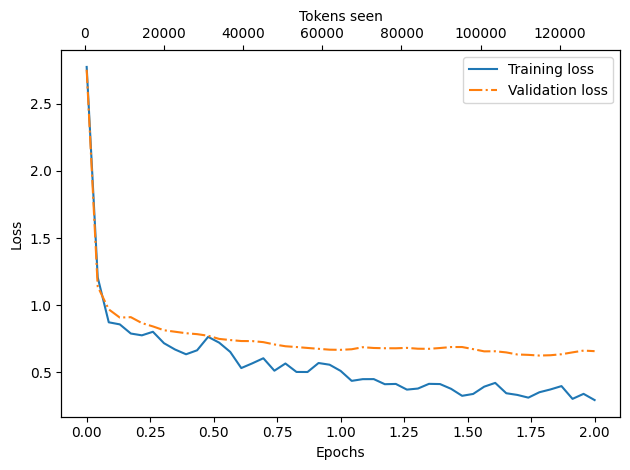

In [73]:
from gpt_train import plot_losses
epochs_tensor = torch.linspace(0 , num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [74]:
torch.manual_seed(123)

for entry in test_data[:3]:
  input_text = format_input(entry)
  token_ids = generate(
      model = model,
      idx = text_to_token_ids(input_text, tokenizer).to(device),
      max_new_tokens=256,
      context_size=BASE_CONFIG["context_length"],
      eos_id=50256
  )
  generated_text = token_ids_to_text(token_ids, tokenizer)

  response_text = (
      generated_text[len(input_text):]
      .replace("### Response:", "")
      .strip()
  )
  print(input_text)
  print(f"\nCorrect response:\n>> {entry['output']}")
  print(f"\nModel response:\n>> {response_text.strip()}")
  print("--"*10)

Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
--------------------
Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
--------------------
Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is Jane Austen.
--------------

In [75]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data) , total=len(test_data)):
  input_text = format_input(entry)

  token_ids = generate(
      model = model,
      idx = text_to_token_ids(input_text , tokenizer).to(device),
      max_new_tokens=256,
      context_size=BASE_CONFIG["context_length"],
      eos_id=50256
  )
  generated_text = token_ids_to_text(token_ids, tokenizer)

  response_text = (
      generated_text[len(input_text):]
      .replace('### Response:' , '')
      .strip()
  )

  test_data[i]["model_reponse"] = response_text

with open("instruction-data-with-response.json" , "w") as file:
  json.dump(test_data, file, indent=4)


100%|██████████| 110/110 [01:09<00:00,  1.58it/s]


In [76]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_reponse': 'The car is as fast as a bullet.'}
